# MOFA+ — Multi-Dataset Methylation Integration
## Step 3: Finding shared CpG signatures across all 9 exposure cohorts

**What MOFA+ does:**
MOFA+ (Multi-Omics Factor Analysis v2) learns *latent factors* — hidden axes of CpG co-variation — that are shared across multiple datasets. Instead of asking "does wildfire change methylation?" (one dataset, low power), it asks: **"which CpG patterns vary consistently across wildfire, stress, obesity, and cfDNA cohorts?"**

**Our design:**
- **Views (2):** `cpgi` and `genebody` — two biological compartments treated as separate data types
- **Groups (9):** one per cohort (wildfire, stress, obesity × 3, cfDNA × 4)
- **Features:** CpG positions — shared reference, `NaN` where a dataset has no coverage
- **Samples:** individual animals within each group

**Why this beats running models separately per dataset:**
Each cohort has n=11–21 (low power). MOFA+ borrows statistical strength across all groups simultaneously. A factor that separates Case/Control in 5 of 9 cohorts is compelling even if no single cohort reaches significance.

**MOFA+ handles missing data natively** — datasets that do not cover a CpG simply contribute `NaN`; the model estimates weights using only observed values.

In [50]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path
from scipy import stats

from mofapy2.run.entry_point import entry_point

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Cell 2 — Configuration

**What to remember:**
- `N_FACTORS` controls model complexity. Start with 5 — more factors = more patterns captured but slower and harder to interpret. You can re-run with 8–10 once you know the data.
- `MIN_COVERAGE` drops CpGs that are missing in too many groups — a fully-missing CpG contributes nothing to MOFA+.
- We run two views (`cpgi`, `genebody`) as separate inputs so MOFA+ can tell us whether a factor is driven by island methylation, gene body methylation, or both.

In [51]:
# ── Paths ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR   = PROJECT_ROOT / 'results' / 'tables'
MOFA_DIR     = PROJECT_ROOT / 'results' / 'mofa'

for d in [FIGURES_DIR, TABLES_DIR, MOFA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── MOFA+ settings ────────────────────────────────────────────────────
N_FACTORS    = 5     # number of latent factors to learn
N_ITER       = 1000  # training iterations (increase to 2000 if not converged)
MIN_COVERAGE = 0.5   # drop CpGs missing in more than 50% of groups

# ── All datasets and regions ──────────────────────────────────────────
DATASETS = [
    'wildfire',
    'stress',
    'obesity_hippocampus',
    'obesity_hypothalamus',
    'obesity_prefrontalcortex',
    'cfdna_GD45',
    'cfdna_GD90',
    'cfdna_GD120',
    'cfdna_GD150',
]
REGIONS = ['cpgi', 'genebody']

print(f'N_FACTORS    : {N_FACTORS}')
print(f'N_ITER       : {N_ITER}')
print(f'MIN_COVERAGE : {MIN_COVERAGE} (drop CpG if missing in >{MIN_COVERAGE*100:.0f}% of groups)')

N_FACTORS    : 5
N_ITER       : 1000
MIN_COVERAGE : 0.5 (drop CpG if missing in >50% of groups)


## Cell 3 — Load and Align All Beta Matrices

**What alignment means:**
Each dataset was preprocessed independently and may cover a slightly different set of CpGs (depending on sequencing depth). MOFA+ requires all groups within a view to have the **same feature columns**. We solve this by:
1. Taking the **union** of all CpG positions across all datasets for each region
2. **Reindexing** each dataset's matrix to the full union — CpGs not covered by that dataset become `NaN`
3. Dropping CpGs missing in more than `MIN_COVERAGE` fraction of groups (they contribute no cross-cohort information)

**`df.reindex(columns=all_cpgs)`** adds the missing columns as `NaN` without changing existing values. It also reorders columns to match the reference set.

In [52]:
view_data   = {}   # view_data[region][dataset] = DataFrame(samples × CpGs)
available   = {}   # track which files exist

for region in REGIONS:
    matrices   = {}
    for ds in DATASETS:
        path = DATA_DIR / f'{ds}_{region}_methylation.csv'
        if path.exists():
            df = pd.read_csv(path, index_col=0).T   # transpose: samples × CpGs
            # Ensure sample index is string (avoids int/str mismatch)
            df.index = df.index.astype(str)
            matrices[ds] = df
            print(f'  Loaded {ds:30s} {region}: {df.shape[0]:3d} samples × {df.shape[1]:3d} CpGs')
        else:
            print(f'  [MISSING] {ds}_{region}_methylation.csv — skipping')

    # ── Union of all CpG positions ──────────────────────────────────
    all_cpgs = sorted(set().union(*[set(df.columns) for df in matrices.values()]))
    print(f'\n  {region}: {len(all_cpgs)} CpGs in union across {len(matrices)} datasets')

    # ── Reindex every dataset to full union (NaN for missing CpGs) ──
    for ds in matrices:
        matrices[ds] = matrices[ds].reindex(columns=all_cpgs)

    # ── Drop CpGs missing in too many groups ─────────────────────────
    # For each CpG, count how many groups have at least 1 non-NaN value
    n_groups    = len(matrices)
    cpg_coverage = pd.DataFrame({
        ds: (~matrices[ds].isna().all(axis=0)).astype(int)
        for ds in matrices
    })
    # cpg_coverage: rows=CpGs, columns=datasets, value=1 if CpG observed in that dataset
    fraction_covered = cpg_coverage.sum(axis=1) / n_groups
    keep_cpgs = fraction_covered[fraction_covered >= MIN_COVERAGE].index
    print(f'  Kept {len(keep_cpgs)}/{len(all_cpgs)} CpGs (coverage >= {MIN_COVERAGE*100:.0f}% of groups)')

    for ds in matrices:
        matrices[ds] = matrices[ds][keep_cpgs]

    view_data[region] = matrices
    available[region] = list(matrices.keys())
    print()

print('Data loading complete.')

  Loaded wildfire                       cpgi:  21 samples ×  42 CpGs
  Loaded stress                         cpgi:  76 samples ×  42 CpGs
  Loaded obesity_hippocampus            cpgi:  13 samples ×  42 CpGs
  Loaded obesity_hypothalamus           cpgi:  13 samples ×  42 CpGs
  Loaded obesity_prefrontalcortex       cpgi:  13 samples ×  42 CpGs
  Loaded cfdna_GD45                     cpgi:  11 samples ×  36 CpGs
  Loaded cfdna_GD90                     cpgi:  11 samples ×  42 CpGs
  Loaded cfdna_GD120                    cpgi:  12 samples ×  42 CpGs
  Loaded cfdna_GD150                    cpgi:  13 samples ×  42 CpGs

  cpgi: 42 CpGs in union across 9 datasets
  Kept 42/42 CpGs (coverage >= 50% of groups)

  Loaded wildfire                       genebody:  21 samples × 245 CpGs
  Loaded stress                         genebody:  76 samples × 241 CpGs
  Loaded obesity_hippocampus            genebody:  13 samples × 241 CpGs
  Loaded obesity_hypothalamus           genebody:  13 samples × 241 C

## Cell 4 — Run MOFA+

**Understanding the model setup:**

`set_data_options(scale_views=False)` — we do NOT scale because both views are already beta values (0–1 range). Scaling would be needed if one view were, say, RNA-seq counts and another were methylation.

`set_model_options(factors=N_FACTORS)` — MOFA+ will learn this many factors. Each factor is a direction in CpG space that explains variance across groups.

`likelihoods=['gaussian', 'gaussian']` — assumes normally distributed noise around factor predictions. Appropriate for beta values (especially after mean imputation keeps most values in the interior of [0,1]).

**Training output to watch:**
- ELBO (Evidence Lower BOund) should increase monotonically — if it decreases, something is wrong
- "Converged" message means the model stopped early because improvement was below threshold

In [53]:
# ── Build MOFA+ data structure ────────────────────────────────────────
# data_dict[view][group] = DataFrame(n_samples × n_features)
# Groups must have same columns within a view; can differ across views
data_dict = {}
for region in REGIONS:
    data_dict[region] = {}
    for ds in available[region]:
        data_dict[region][ds] = view_data[region][ds]
        # MOFA+ tolerates NaN within a matrix (missing sample/CpG combinations)

# ── Run MOFA+ ─────────────────────────────────────────────────────────
print('Setting up MOFA+ model...')
ent = entry_point()

ent.set_data_matrix(
    data_dict,
    likelihoods=['gaussian'] * len(REGIONS)
    # One likelihood per VIEW, not per group
)

ent.set_data_options(
    scale_views=False,   # all views already on same 0–1 beta scale
    scale_groups=False   # do not standardise across groups
)
ent.set_model_options(
    factors=N_FACTORS,
    ard_factors=False,
    ard_weights=False,
    spikeslab_factors=False,
    spikeslab_weights=False,
)

ent.set_train_options(
    iter=N_ITER,
    convergence_mode='slow',
    seed=42,
    verbose=True,
)

print('Building model...')
ent.build()

print(f'Training MOFA+ with {N_FACTORS} factors × {len(REGIONS)} views × {len(DATASETS)} groups...')
ent.run()

# Save explicitly after training
outfile = str(MOFA_DIR / 'mofa_model.hdf5')
ent.save(outfile=outfile)
print(f'Model saved to: {outfile}') 

print('\nMOFA+ training complete.')

Setting up MOFA+ model...

        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


View names not provided, using default naming convention:
- view1, view2, ..., viewM

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_gr

In [60]:
def print_hdf5_structure(f, indent=0):
    for key in f.keys():
        print(' ' * indent + key)
        if hasattr(f[key], 'keys'):
            print_hdf5_structure(f[key], indent + 2)

with h5py.File(MOFA_DIR / 'mofa_model.hdf5', 'r') as f:
    print_hdf5_structure(f)

data
  view0
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
  view1
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
expectations
  W
    view0
    view1
  Z
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
features
  view0
  view1
groups
  groups
intercepts
  view0
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
  view1
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    group8
model_options
  ard_factors
  ard_weights
  likelihoods
  spikeslab_factors
  spikeslab_weights
samples
  group0
  group1
  group2
  group3
  group4
  group5
  group6
  group7
  group8
training_opts
training_stats
  elbo
  number_factors
  time
variance_explained
  r2_per_factor
    group0
    group1
    group2
    group3
    group4
    group5
    group6
    group7
    gro

## Cell 5 — Extract Results

After training, MOFA+ stores everything in an HDF5 file. We extract:
- **Z (factor scores):** one matrix per group, shape `(n_samples, n_factors)` — where each animal sits in factor space
- **W (weights/loadings):** one matrix per view, shape `(n_cpgs, n_factors)` — how much each CpG contributes to each factor
- **R² (variance explained):** how much variance each factor explains per view and per group

In [88]:
# ── Load results from saved HDF5 ──────────────────────────────────────
mofa_file = MOFA_DIR / 'mofa_model.hdf5'

factor_scores = {}
cpg_weights   = {}
r2_dict       = {}

factor_cols = [f'Factor{i+1}' for i in range(N_FACTORS)]

with h5py.File(mofa_file, 'r') as f:

    # Get actual names from the file (not assumed)
    groups     = [g.decode() if isinstance(g, bytes) else g for g in f['groups']['groups'][:]]
    views      = [v.decode() if isinstance(v, bytes) else v for v in f['views']['views'][:]]
    group_keys = [f'group{i}' for i in range(len(groups))]
    view_keys  = [f'view{i}'  for i in range(len(views))]

    print(f'Groups : {groups}')
    print(f'Views  : {views}')

    # Factor scores per group
    for gkey, grp in zip(group_keys, groups):
        Z       = f['expectations']['Z'][gkey][:]          # (n_factors, n_samples)
        Z       = Z.T                                       # → (n_samples, n_factors)
        samples = [s.decode() if isinstance(s, bytes) else s
                   for s in f['samples'][gkey][:]]
        factor_scores[grp] = pd.DataFrame(Z, index=samples,
                                          columns=factor_cols[:Z.shape[1]])

    # CpG weights per view
    for vkey, view in zip(view_keys, views):
        W        = f['expectations']['W'][vkey][:]         # (n_factors, n_cpgs)
        W        = W.T                                      # → (n_cpgs, n_factors)
        features = [feat.decode() if isinstance(feat, bytes) else feat
                    for feat in f['features'][vkey][:]]
        cpg_weights[view] = pd.DataFrame(W, index=features,
                                         columns=factor_cols[:W.shape[1]])

    # Variance explained — r2_per_factor/groupX has shape (n_views, n_factors)
    for view in views:
        r2_dict[view] = {}
    for gkey, grp in zip(group_keys, groups):
        r2 = f['variance_explained']['r2_per_factor'][gkey][:]  # (n_views, n_factors)
        for j, view in enumerate(views):
            r2_dict[view][grp] = r2[j]   # one array of length n_factors
# Use DATASETS and REGIONS — we know the order they were fed to MOFA+
factor_scores = {DATASETS[i]: factor_scores[f'group{i}'] for i in range(len(DATASETS))}
cpg_weights   = {REGIONS[i]:  cpg_weights[f'view{i}']   for i in range(len(REGIONS))}
r2_dict       = {REGIONS[i]:  r2_dict[f'view{i}']        for i in range(len(REGIONS))}

print('Renamed keys:')
print('  factor_scores:', list(factor_scores.keys()))
print('  cpg_weights:  ', list(cpg_weights.keys()))

print('\nFactor score shapes:')
for grp, df in factor_scores.items():
    print(f'  {grp:35s}: {df.shape}')
print('\nCpG weight shapes:')
for view, df in cpg_weights.items():
    print(f'  {view:15s}: {df.shape}')
# Restore real sample names — mofapy2 replaces them with sample0_group0 etc.
for ds in DATASETS:
    if ds in factor_scores and ds in view_data[REGIONS[0]]:
        real_samples = view_data[REGIONS[0]][ds].index.tolist()
        factor_scores[ds].index = real_samples
        
# Verify
print('Sample names restored:')
for ds in ['wildfire', 'stress']:
    print(f'  {ds}: {factor_scores[ds].index[:3].tolist()}')

Groups : ['group0', 'group1', 'group2', 'group3', 'group4', 'group5', 'group6', 'group7', 'group8']
Views  : ['view0', 'view1']
Renamed keys:
  factor_scores: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
  cpg_weights:   ['cpgi', 'genebody']

Factor score shapes:
  wildfire                           : (21, 5)
  stress                             : (76, 5)
  obesity_hippocampus                : (13, 5)
  obesity_hypothalamus               : (13, 5)
  obesity_prefrontalcortex           : (13, 5)
  cfdna_GD45                         : (11, 5)
  cfdna_GD90                         : (11, 5)
  cfdna_GD120                        : (12, 5)
  cfdna_GD150                        : (13, 5)

CpG weight shapes:
  cpgi           : (42, 5)
  genebody       : (241, 5)
Sample names restored:
  wildfire: ['HJD025', 'HJD026', 'HJD027']
  stress: ['MC03', 'MC09', 'MC10']


In [89]:
# Check 1: did the model actually train?
with h5py.File(mofa_file, 'r') as f:
    elbo = f['training_stats']['elbo'][:]
    print(f'ELBO trajectory (first 10): {elbo[:10]}')
    print(f'ELBO trajectory (last 5):   {elbo[-10:]}')
    print(f'Total iterations run: {len(elbo)}')

# Check 2: how much of the data fed to MOFA+ is NaN?
print('\nNaN fraction per view/group:')
for region, mats in view_data.items():
    for ds, df in mats.items():
        nan_frac = df.isna().sum().sum() / df.size
        print(f'  {region} / {ds:30s}: {nan_frac:.1%} NaN')

ELBO trajectory (first 10): [-225804.43293743  -11315.9815118     3323.49974572    5096.80399421
    5533.31430394    6001.92185334    6439.13431484    6952.33903795
    7293.57112788    7468.09243074]
ELBO trajectory (last 5):   [9618.34593585 9618.42918472 9618.51238674 9618.59554198 9618.6786505
 9618.76171236 9618.84472763 9618.92769636 9619.01061862           nan]
Total iterations run: 1001

NaN fraction per view/group:
  cpgi / wildfire                      : 0.0% NaN
  cpgi / stress                        : 0.0% NaN
  cpgi / obesity_hippocampus           : 0.0% NaN
  cpgi / obesity_hypothalamus          : 0.0% NaN
  cpgi / obesity_prefrontalcortex      : 0.0% NaN
  cpgi / cfdna_GD45                    : 14.3% NaN
  cpgi / cfdna_GD90                    : 0.0% NaN
  cpgi / cfdna_GD120                   : 0.0% NaN
  cpgi / cfdna_GD150                   : 0.0% NaN
  genebody / wildfire                      : 0.0% NaN
  genebody / stress                        : 0.0% NaN
  genebody /

In [90]:
print('r2_dict keys:', list(r2_dict.keys()))
for view in r2_dict:
    print(f'\nView: {view}')
    for grp, vals in r2_dict[view].items():
        print(f'  {grp}: {vals}')

r2_dict keys: ['cpgi', 'genebody']

View: cpgi
  group0: [3.99942399 0.51968298 0.51152142 0.40611017 3.40121254]
  group1: [4.01430879e+01 8.54065057e+00 2.02857101e-03 7.30402641e-02
 4.64462604e+00]
  group2: [ 0.6446865   0.1549698  -0.0024272   0.02943019  0.15877703]
  group3: [ 1.73439930e+01 -2.65186820e-01  5.36930502e-04  3.43452163e-01
 -3.25188425e+00]
  group4: [ 9.99220017e+00  5.69077236e+01  3.96536896e-02  5.23758402e-03
 -1.80153701e+00]
  group5: [ 4.72687456e+00  3.48883777e-01 -2.30634402e-04  2.53678961e-02
 -2.62374036e-02]
  group6: [ 0.75323057  0.05216366 -0.00235111  0.00243862  0.08624771]
  group7: [ 0.64730049  0.07328997 -0.06666613  0.40492569  0.13177798]
  group8: [ 0.00315725  0.06049423  0.92551799 -0.06135359  0.01516599]

View: genebody
  group0: [0.30802722 0.12498681 5.01659753 1.10807286 0.46545214]
  group1: [3.08166135 0.62995793 1.77130493 1.04755686 1.10334472]
  group2: [0.00439027 0.00720799 0.03348313 0.06839816 0.00597941]
  group3: [0.1

## Cell 6 — Variance Explained

The variance explained heatmap shows which factors matter most in which cohorts and which view (cpgi vs genebody). This is the first diagnostic plot — it tells you:
- **Bright cells** = that factor explains a lot of variation in that group
- **Factors that light up across many groups** = shared biological signal
- **Factors that light up in only one group** = cohort-specific effect (still interesting!)

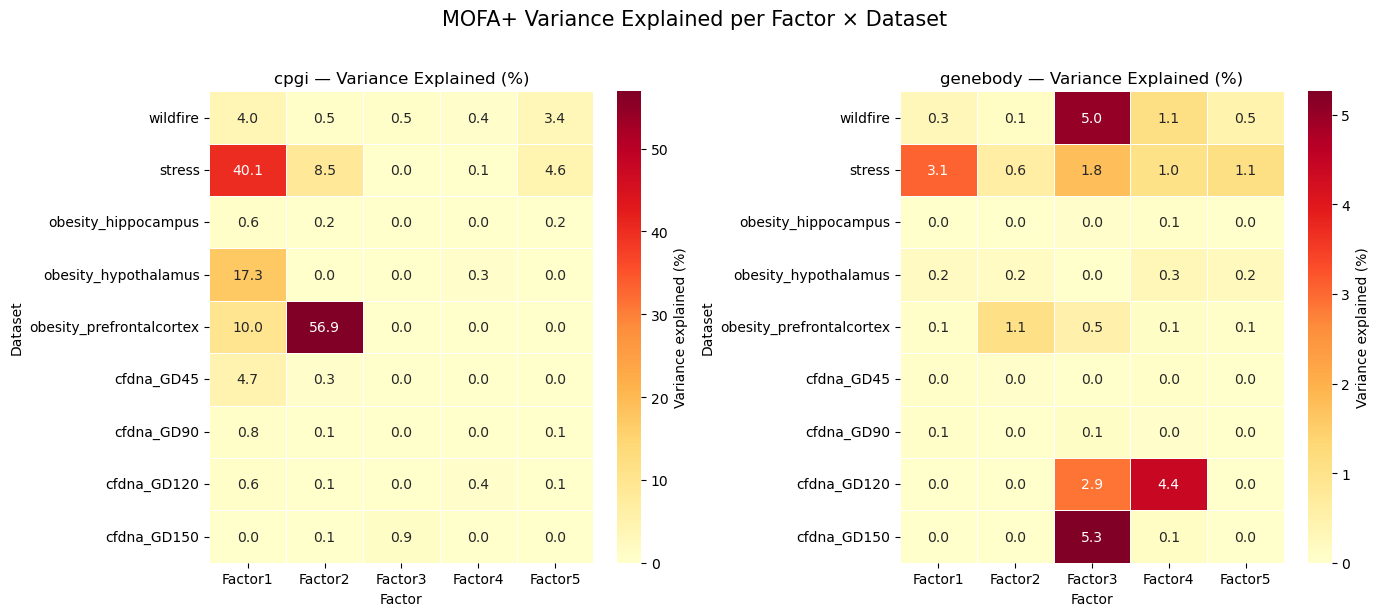

In [93]:
# Map group/view keys to real names
with h5py.File(mofa_file, 'r') as f:
    groups = [g.decode() if isinstance(g, bytes) else g for g in f['groups']['groups'][:]]
    views  = [v.decode() if isinstance(v, bytes) else v for v in f['views']['views'][:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col_idx, region in enumerate(REGIONS):
    r2_matrix = pd.DataFrame(r2_dict[region]).T
    r2_matrix.index   = DATASETS                    # ← add this line
    r2_matrix.columns = factor_cols[:r2_matrix.shape[1]]
    r2_matrix = r2_matrix.clip(lower=0)

    sns.heatmap(
        r2_matrix,
        annot=True, fmt='.1f',
        cmap='YlOrRd',
        vmin=0,
        linewidths=0.5,
        ax=axes[col_idx],
        cbar_kws={'label': 'Variance explained (%)'}
    )
    axes[col_idx].set_title(f'{region} — Variance Explained (%)')
    axes[col_idx].set_xlabel('Factor')
    axes[col_idx].set_ylabel('Dataset')

plt.suptitle('MOFA+ Variance Explained per Factor × Dataset', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mofa_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
print('factor_scores keys:', list(factor_scores.keys()))
print('all_labels keys:   ', list(all_labels.keys()))

# Check one sample
grp = 'wildfire'
print(f'\nfactor_scores[{grp}].index:', factor_scores[grp].index.tolist())
print(f'all_labels[{grp}].index:   ', all_labels[grp].index.tolist())

factor_scores keys: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
all_labels keys:    ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']

factor_scores[wildfire].index: ['HJD025', 'HJD026', 'HJD027', 'HJD028', 'HJD030', 'HJD031', 'HJD032', 'HJD033', 'HJD034', 'HJD035', 'HJD036', 'HJD037', 'HJD038', 'HJD039', 'HJD040', 'HJD041', 'HJD042', 'HJD043', 'HJD044', 'HJD045', 'HJD046']
all_labels[wildfire].index:    ['HJD025', 'HJD026', 'HJD027', 'HJD028', 'HJD030', 'HJD031', 'HJD032', 'HJD033', 'HJD034', 'HJD035', 'HJD036', 'HJD037', 'HJD038', 'HJD039', 'HJD040', 'HJD041', 'HJD042', 'HJD043', 'HJD044', 'HJD045', 'HJD046']


## Cell 7 — Factor Scores Coloured by Case/Control

For each dataset and each factor, we plot the factor scores split by case vs control. A factor that consistently separates case from control across multiple cohorts is the most important finding — it represents a shared methylation signature of early-life exposure.

**How to read these plots:**
- X-axis: factor score for each animal
- Groups: Control (blue) vs Case (red)
- If the distributions separate → this factor captures exposure-related variation in that cohort

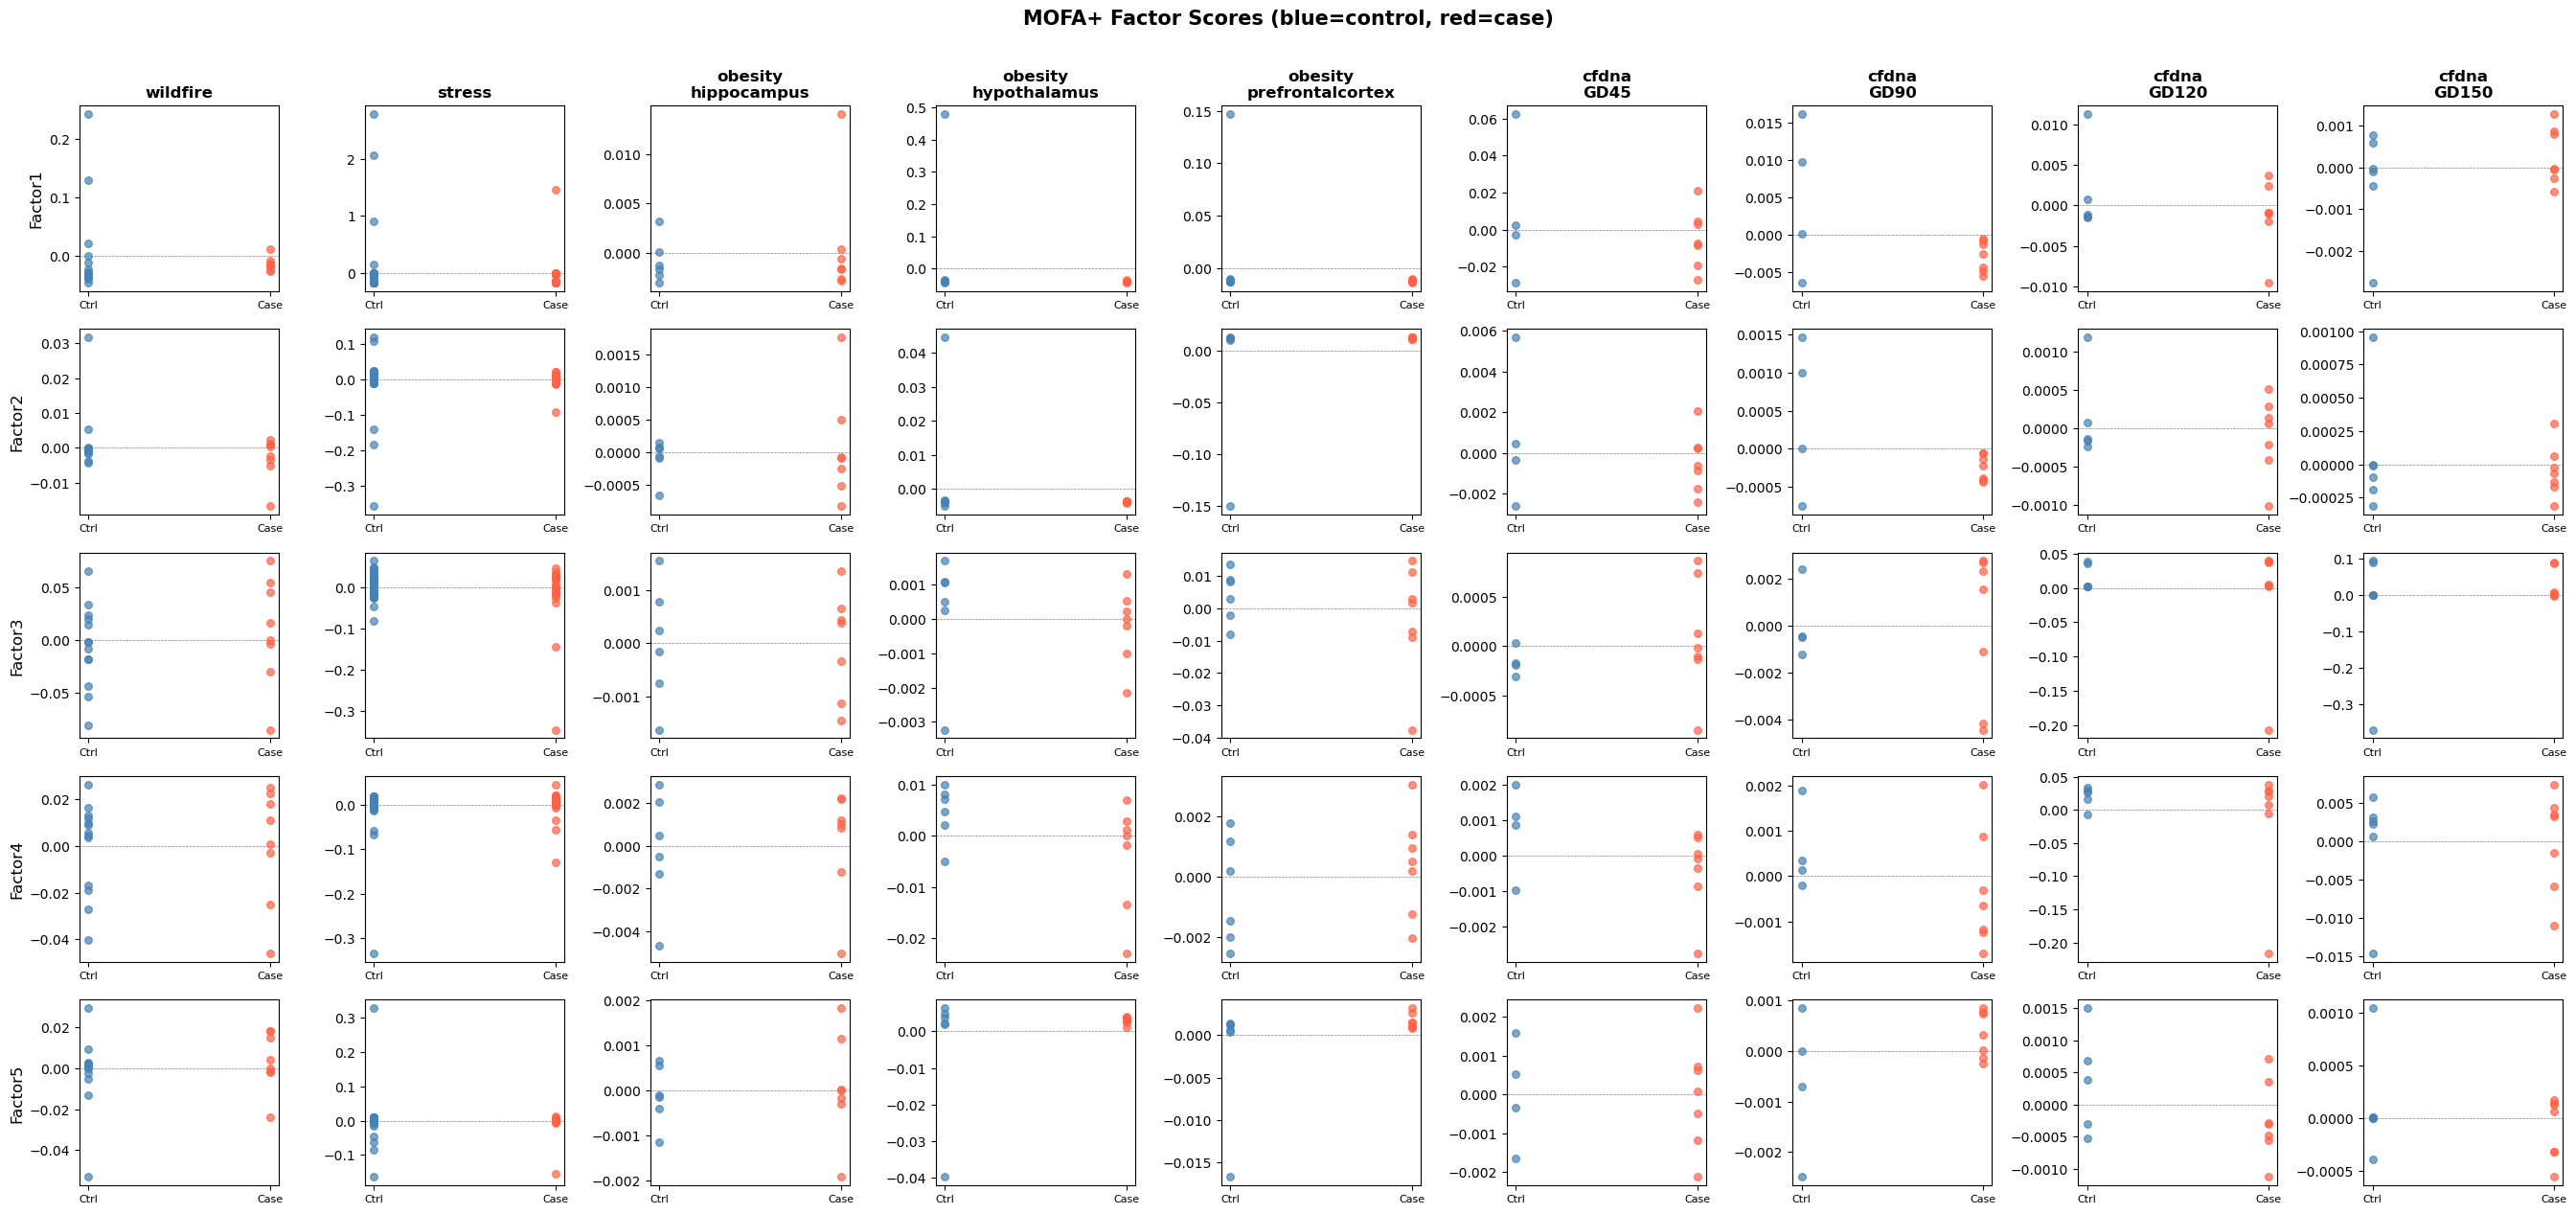

Saved: mofa_factor_scores.png


In [100]:
# ── Load labels for all datasets ─────────────────────────────────────
all_labels = {}
for ds in DATASETS:
    lpath = DATA_DIR / f'{ds}_labels.csv'
    if lpath.exists():
        lab = pd.read_csv(lpath, index_col='sample_id')
        lab.index = lab.index.astype(str)
        all_labels[ds] = lab['label']

# ── Factor score strip plots ──────────────────────────────────────────
n_groups_avail = len(factor_scores)
fig, axes = plt.subplots(
    N_FACTORS, n_groups_avail,
    figsize=(3 * n_groups_avail, 2.5 * N_FACTORS),
    squeeze=False
)

group_list = list(factor_scores.keys())
colors     = {0: 'steelblue', 1: 'tomato'}

for fi, factor in enumerate(factor_cols):
    for gi, grp in enumerate(group_list):
        ax    = axes[fi, gi]
        scores = factor_scores[grp][factor]

        if grp in all_labels:
            y = all_labels[grp].reindex(scores.index)
            for val, color in colors.items():
                mask = y == val
                ax.scatter(
                    [val] * mask.sum(),
                    scores[mask],
                    c=color, alpha=0.7, s=30, zorder=3
                )
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Ctrl', 'Case'], fontsize=8)
        else:
            ax.plot(scores.values, 'o', color='grey', ms=4)

        ax.set_ylabel(factor if gi == 0 else '', fontsize=12)
        ax.set_title(grp.replace('_', '\n') if fi == 0 else '', fontsize=12, fontweight="bold")
        ax.axhline(0, color='grey', lw=0.5, ls='--')

plt.suptitle('MOFA+ Factor Scores (blue=control, red=case)', fontsize=15, y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mofa_factor_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mofa_factor_scores.png')

## Cell 8 — Top CpG Weights per Factor

The weights tell you **which CpGs drive each factor**. High positive weight = CpG is more methylated in samples with high factor scores. High negative weight = CpG is less methylated.

These are your candidate CpGs for the per-CpG meta-analysis in the next step. A CpG that has a high weight in a factor that also separates case/control is your primary hit.

In [96]:
# ── Top CpG weights per factor per view ──────────────────────────────
N_TOP = 10  # top CpGs to show per factor

for region in REGIONS:
    if region not in cpg_weights:
        continue
    W = cpg_weights[region]
    print(f'\n── {region.upper()} — Top {N_TOP} CpGs per Factor ──')
    for factor in factor_cols:
        top = W[factor].abs().sort_values(ascending=False).head(N_TOP)
        print(f'\n  {factor}:')
        for cpg, weight in top.items():
            direction = '+' if W.loc[cpg, factor] > 0 else '-'
            print(f'    {direction}{weight:.4f}  {cpg}')

# ── Save weights ──────────────────────────────────────────────────────
for region in REGIONS:
    if region in cpg_weights:
        cpg_weights[region].to_csv(TABLES_DIR / f'mofa_weights_{region}.csv')
        print(f'\nSaved: mofa_weights_{region}.csv')

for grp in factor_scores:
    factor_scores[grp].to_csv(TABLES_DIR / f'mofa_scores_{grp}.csv')
print('Saved: mofa_scores_*.csv for all groups')


── CPGI — Top 10 CpGs per Factor ──

  Factor1:
    +0.3995  feature37_view0
    +0.3985  feature36_view0
    +0.3981  feature38_view0
    +0.3858  feature39_view0
    +0.3803  feature41_view0
    +0.3692  feature35_view0
    +0.3455  feature40_view0
    +0.3355  feature33_view0
    +0.3328  feature34_view0
    +0.3237  feature31_view0

  Factor2:
    -2.5081  feature12_view0
    -2.4121  feature10_view0
    -2.3109  feature11_view0
    -1.7677  feature15_view0
    -1.7478  feature14_view0
    -1.7127  feature16_view0
    -1.6968  feature13_view0
    -1.5252  feature9_view0
    -1.4297  feature7_view0
    -1.3134  feature4_view0

  Factor3:
    +0.1341  feature3_view0
    +0.0885  feature2_view0
    -0.0685  feature19_view0
    +0.0380  feature39_view0
    -0.0285  feature28_view0
    +0.0236  feature8_view0
    +0.0218  feature4_view0
    -0.0195  feature30_view0
    -0.0171  feature13_view0
    -0.0167  feature22_view0

  Factor4:
    +0.3012  feature28_view0
    +0.2697  feature27_

## Cell 9 — Factor–Label Association (Mann-Whitney U test)

For each factor × group combination where we have case/control labels, we test whether factor scores differ significantly between groups using a Mann-Whitney U test (non-parametric, appropriate for small n).

**What to look for:**
- Low p-values (< 0.05) after correction = factor is associated with exposure in that cohort
- If the same factor is significant in 2+ cohorts → strongest evidence of a shared signature

**Bonferroni correction** divides the significance threshold by the number of tests. It is conservative (may miss real effects) but appropriate as a first pass.

In [97]:
print('factor_scores keys:', list(factor_scores.keys()))
print('all_labels keys:   ', list(all_labels.keys()))

factor_scores keys: ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']
all_labels keys:    ['wildfire', 'stress', 'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex', 'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150']


In [98]:
from scipy.stats import mannwhitneyu

results = []
n_tests = 0

for factor in factor_cols:
    for grp in factor_scores:
        if grp not in all_labels:
            continue
        scores = factor_scores[grp][factor]
        y      = all_labels[grp].reindex(scores.index).dropna()
        scores = scores.reindex(y.index)

        ctrl = scores[y == 0]
        case = scores[y == 1]

        if len(ctrl) < 3 or len(case) < 3:
            # Too few samples for a meaningful test
            continue

        stat, pval = mannwhitneyu(ctrl, case, alternative='two-sided')
        n_tests   += 1
        results.append({
            'factor'       : factor,
            'dataset'      : grp,
            'n_ctrl'       : len(ctrl),
            'n_case'       : len(case),
            'median_ctrl'  : round(ctrl.median(), 4),
            'median_case'  : round(case.median(), 4),
            'MW_stat'      : round(stat, 2),
            'p_value'      : round(pval, 4),
        })

results_df = pd.DataFrame(results)

if results_df.empty:
    print('No tests ran — keys do not overlap between factor_scores and all_labels')
    print('factor_scores keys:', list(factor_scores.keys()))
    print('all_labels keys:   ', list(all_labels.keys()))
else:
    results_df = results_df.sort_values('p_value')
    alpha_corrected = 0.05 / max(n_tests, 1)
    results_df['significant_bonferroni'] = results_df['p_value'] < alpha_corrected

    print(f'Total tests: {n_tests}')
    print(f'Bonferroni threshold: p < {alpha_corrected:.4f}')
    print('\n── Top associations (sorted by p-value) ──')
    display(results_df.head(20))

    results_df.to_csv(TABLES_DIR / 'mofa_factor_label_association.csv', index=False)
    print('\nSaved: mofa_factor_label_association.csv')

Total tests: 45
Bonferroni threshold: p < 0.0011

── Top associations (sorted by p-value) ──


,factor,dataset,n_ctrl,n_case,median_ctrl,median_case,MW_stat,p_value,significant_bonferroni
30,Factor4,obesity_hypothalamus,6,7,0.0059,0.0000,34.0,0.0734,False
40,Factor5,obesity_prefrontalcortex,6,7,0.0009,0.0016,9.0,0.1014,False
10,Factor2,stress,52,24,0.0103,0.0073,751.0,0.1575,False
32,Factor4,cfdna_GD45,4,7,0.0010,-0.0001,22.0,0.1636,False
33,Factor4,cfdna_GD90,4,7,0.0002,-0.0007,21.0,0.2303,False
6,Factor1,cfdna_GD90,4,7,0.0049,-0.0026,21.0,0.2303,False
15,Factor2,cfdna_GD90,4,7,0.0005,-0.0002,21.0,0.2303,False
23,Factor3,cfdna_GD45,4,7,-0.0002,-0.0000,7.0,0.2303,False
13,Factor2,obesity_prefrontalcortex,6,7,0.0123,0.0130,12.0,0.2343,False
43,Factor5,cfdna_GD120,5,7,0.0004,-0.0003,25.0,0.2677,False



Saved: mofa_factor_label_association.csv
